# **Fraud Detection Using Machine Learning**

# End-to-end analysis and classification of fraudulent financial transactions

Financial fraud results in significant economic losses each year.
This project aims to build and evaluate a machine learning model capable of identifying fraudulent transactions using historical transaction data.

## Problem Statement


The objective of this project is to identify fraudulent transactions from a highly imbalanced financial dataset.
The challenge lies in accurately detecting fraud while minimizing false negatives, as missed fraud cases carry high financial risk.


## Dataset Overview

- Records of financial transactions
- Target variable: `isFraud`
- Contains both numerical and categorical features
- Dataset is highly imbalanced


## Importing Libraries and Dataset

This project uses Python-based data analysis and visualization libraries to perform exploratory analysis, preprocessing, and model development.

- **Pandas**: Used for data loading, manipulation, and exploratory analysis.
- **NumPy**: Provides efficient numerical computations and array operations.
- **Matplotlib & Seaborn**: Used for data visualization to identify patterns and trends within the dataset.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Dataset Description and Loading

The dataset contains transactional features such as payment type, transaction amount, account balances before and after transactions, and destination account information. These features are used to identify patterns associated with fraudulent activity.


In [5]:
data = pd.read_csv("data/fraud_detection_dataset.csv")
data.head()

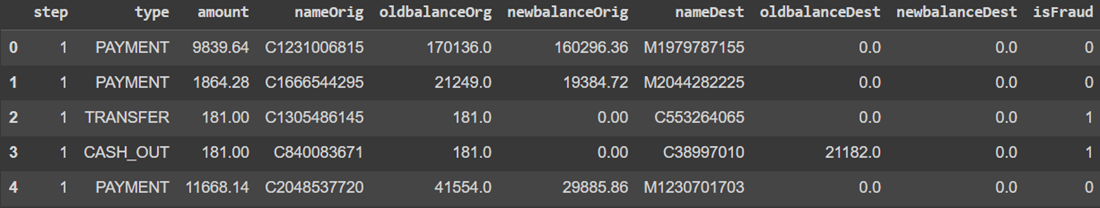

## Dataset Structure

To understand the structure of the dataset, including data types and missing values, the dataset information is reviewed below.


data.info()


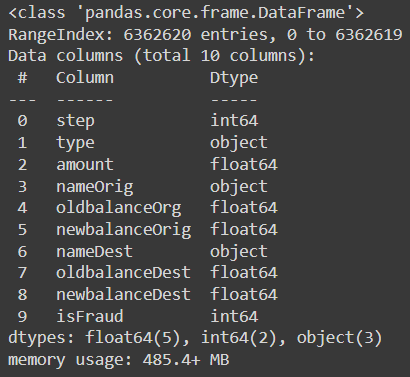

## Statistical Summary

Descriptive statistics were computed to understand the central tendency, spread, and range of numerical features within the dataset.


In [ ]:
data.describe()

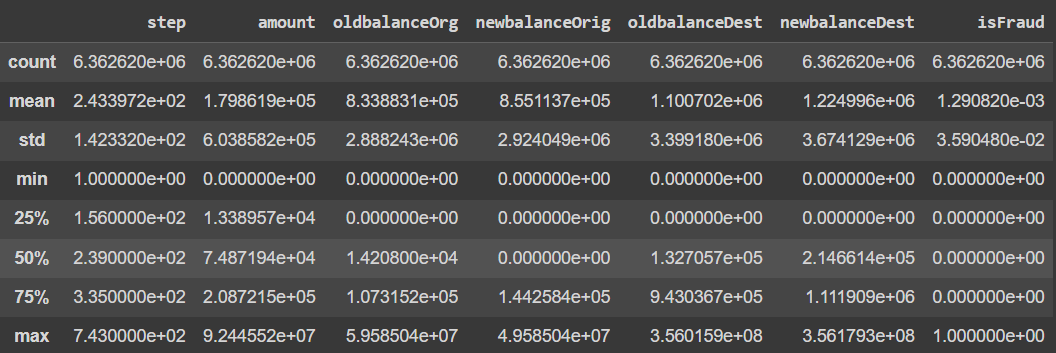

### Key Observations

- Transaction amounts exhibit a wide range, indicating the presence of both low- and high-value transactions.
- Account balance features show significant variability, which may be indicative of abnormal behavior in fraudulent transactions.
- The presence of extreme values suggests the need for robust models capable of handling outliers.


## Exploratory Data Analysis and Visualization

Exploratory data analysis was performed to understand feature distributions, data types, and relationships between variables, with a focus on identifying patterns associated with fraudulent transactions.


### Feature Type Analysis

The dataset contains a mix of categorical and numerical variables. Identifying feature types helps determine appropriate preprocessing and modeling strategies.


In [ ]:
# Identify categorical and numerical features
object_cols = data.select_dtypes(include='object').columns
int_cols = data.select_dtypes(include='int').columns
float_cols = data.select_dtypes(include='float').columns

print("Categorical variables:", len(object_cols))
print("Integer variables:", len(int_cols))
print("Float variables:", len(float_cols))


Categorical variables: 3

Integer variables: 2

Float variables: 5

### Transaction Type Distribution

The distribution of transaction types was analyzed to identify payment methods commonly associated with fraudulent activity.


In [ ]:
sns.countplot(x='type', data=data)
plt.title("Transaction Type Distribution")
plt.show()


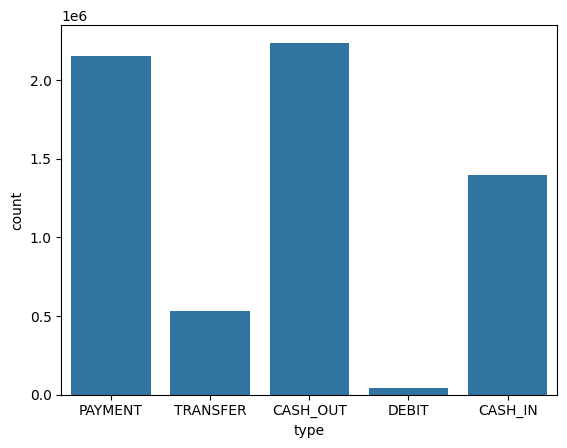

Cash-out and transfer transactions occur most frequently, suggesting that these transaction types may carry a higher exposure to fraud risk.


### Transaction Amount by Payment Type

The relationship between transaction type and transaction amount was examined to identify high-risk transaction categories.


In [ ]:
sns.barplot(x='type', y='amount', data=data)
plt.title("Average Transaction Amount by Type")
plt.show()


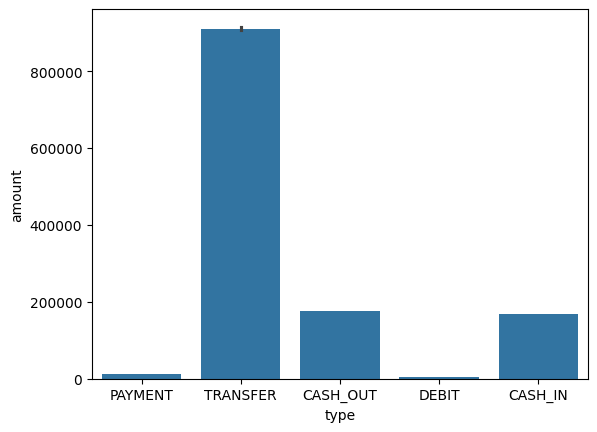

Cash-out and transfer transactions not only occur most frequently but also involve higher transaction amounts, making them critical targets for fraud detection.


### Fraud vs Non-Fraud Distribution

The distribution of fraudulent and non-fraudulent transactions was analyzed to assess class imbalance.


In [ ]:
data['isFraud'].value_counts()


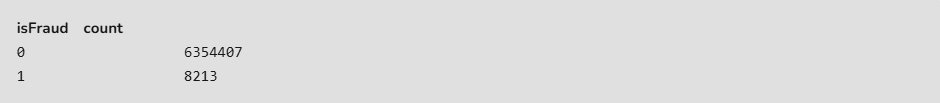

The dataset is highly imbalanced, with fraudulent transactions representing a very small proportion of total records. This imbalance must be considered during model evaluation, particularly by prioritizing recall and F1-score over accuracy.


### Transaction Timing Analysis

The distribution of the `step` feature was analyzed to understand temporal transaction patterns.


In [ ]:
plt.figure(figsize=(15, 6))
sns.histplot(data['step'], bins=50, kde=True)
plt.title("Distribution of Transaction Steps")
plt.xlabel("Step")
plt.ylabel("Density")
plt.show()


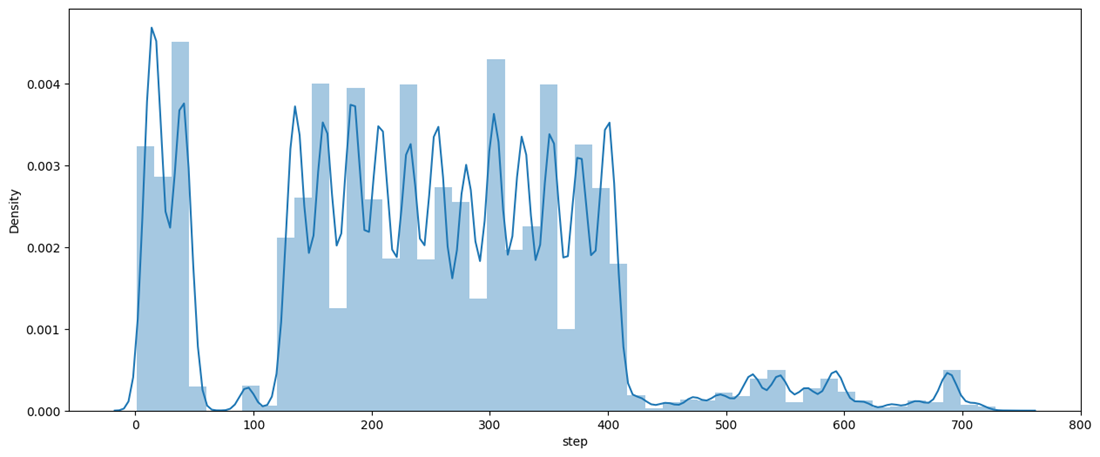

Most transactions occur between steps 200 and 400, indicating peak transaction activity during this period, which may influence fraud detection sensitivity.


### Correlation Analysis

A correlation heatmap was generated to examine relationships between features and identify potential multicollinearity.


In [ ]:
plt.figure(figsize=(12, 6))
sns.heatmap(data.apply(lambda x: pd.factorize(x)[0]).corr(),
			cmap='BrBG',
			fmt='.2f',
			linewidths=2,
			annot=True)

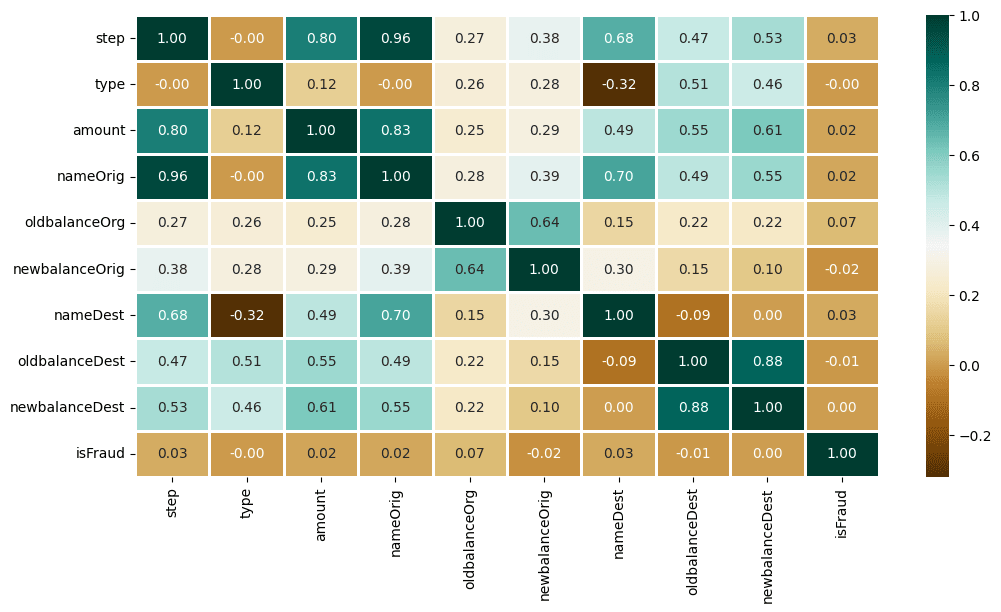

Several balance-related features exhibit strong correlations, indicating potential redundancy. Tree-based models such as XGBoost are well-suited to handle correlated features effectively.


## Data Preprocessing and Feature Engineering

This stage focuses on preparing the dataset for machine learning by encoding categorical variables, removing irrelevant identifiers, and splitting the data into training and testing sets.


### Encoding Categorical Variables

The transaction type feature was encoded using one-hot encoding to convert categorical values into a numerical format suitable for machine learning models.


In [ ]:
type_new = pd.get_dummies(data['type'], drop_first=True)
data_new = pd.concat([data, type_new], axis=1)
data_new.head()

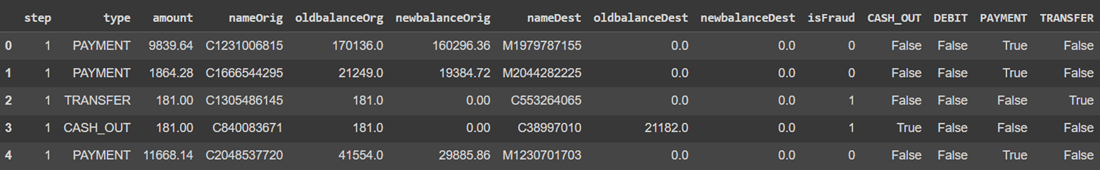

### Feature Selection

Identifier columns that do not contribute predictive value were removed to prevent noise and data leakage.


In [ ]:
X = data_new.drop(['isFraud', 'type', 'nameOrig', 'nameDest'], axis=1)
y = data_new['isFraud']


In [ ]:
X.shape, y.shape

((6362620, 10), (6362620,))

### Train–Test Split

The dataset was split into training and testing sets to evaluate model performance on unseen data.


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


## Model Training and Evaluation

Multiple classification models were trained to evaluate their ability to distinguish between fraudulent and non-fraudulent transactions.  


Model performance was assessed using the **ROC-AUC score**, which measures a model’s ability to rank positive (fraudulent) cases higher than negative ones.


### Models Used

- **Logistic Regression**: A baseline linear classifier used to estimate class probabilities.
- **Random Forest Classifier**: An ensemble-based model capable of capturing non-linear feature interactions.
- **XGBoost Classifier**: A gradient-boosted decision tree model optimized for high predictive performance on structured data.


In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score as ras
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

models = [LogisticRegression(), XGBClassifier(),
          RandomForestClassifier(n_estimators=7,
                                 criterion='entropy',
                                 random_state=7)]

for i in range(len(models)):
    models[i].fit(X_train, y_train)
    print(f'{models[i]} : ')

    train_preds = models[i].predict_proba(X_train)[:, 1]
    print('Training Accuracy : ', ras(y_train, train_preds))

    y_preds = models[i].predict_proba(X_test)[:, 1]
    print('Validation Accuracy : ', ras(y_test, y_preds))
    print()


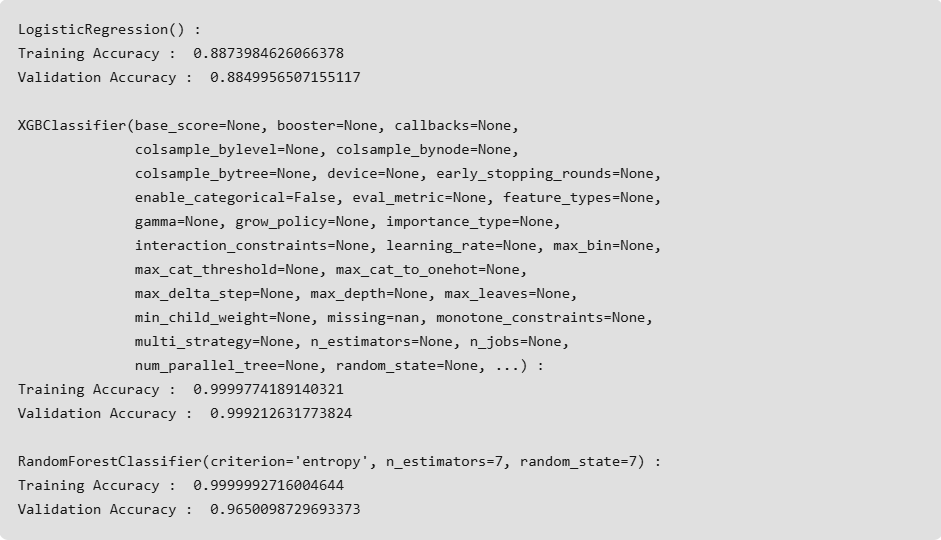

> **Note:**  
> Although labeled as "Accuracy" in the output, the reported values represent **ROC-AUC scores**, not classification accuracy.  
> ROC-AUC is a more appropriate metric for evaluating model performance on highly imbalanced datasets such as fraud detection.


### Model Performance Summary

- Logistic Regression provides a reasonable baseline performance.
- Random Forest demonstrates strong training performance but shows reduced generalization on the validation set.
- XGBoost achieves the highest ROC-AUC score on both training and validation data, indicating superior discriminatory power.


The strong ROC-AUC performance of XGBoost indicates its effectiveness in ranking fraudulent transactions higher than legitimate ones.  
However, due to the highly imbalanced nature of fraud data, further evaluation using recall and precision is required before deployment.


## Model Evaluation

Based on validation performance, the XGBoost classifier was selected as the best-performing model.  
The confusion matrix below illustrates the model’s classification performance on the test dataset.


In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = ConfusionMatrixDisplay.from_estimator(models[1], X_test, y_test)

cm.plot(cmap='Blues')

plt.show()

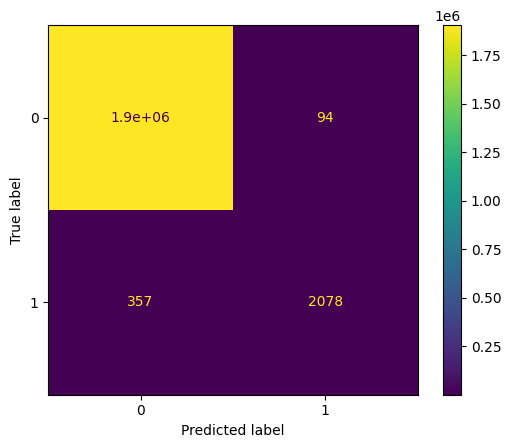

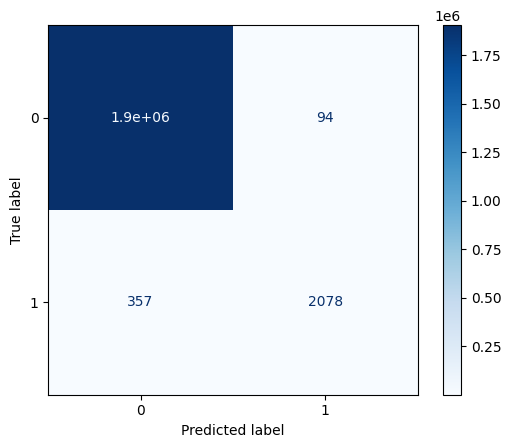

### Confusion Matrix Interpretation

The confusion matrix highlights the model’s ability to correctly classify non-fraudulent transactions while identifying a subset of fraudulent cases.  
Due to the highly imbalanced nature of fraud data, minimizing false negatives remains a critical objective for real-world deployment.


## Conclusion and Business Impact

In this project, I explored how machine learning can be used to detect fraudulent online payment transactions using historical transaction data. The analysis started with understanding the data through exploratory analysis, where clear patterns such as class imbalance and transaction behavior were identified.

After preprocessing and feature engineering, multiple classification models were trained and evaluated. Since fraud detection involves a highly imbalanced dataset, ROC-AUC was used as the primary evaluation metric. Among all the models, XGBoost delivered the best performance, showing a strong ability to differentiate between fraudulent and legitimate transactions.

The confusion matrix revealed that while the model performs very well in identifying non-fraudulent transactions, detecting fraud remains a challenging task due to its rare occurrence. In a real-world setting, this model could be used to flag high-risk transactions for manual review, helping financial institutions reduce potential losses while maintaining efficient transaction processing.

Overall, this project highlights the practical application of machine learning in financial fraud detection and emphasizes the importance of choosing appropriate evaluation metrics and models for imbalanced classification problems.
